# Pré-processamento das Bases da SSP-SP
O objetivo é consolidar as fontes obtidas pela transparência da **Secretária de Segurança Pública de São Paulo (SPP-SP)** em um único **dataset**.

## 1. Bibliotecas e Configuração Inicial

In [67]:
import pandas as pd
import numpy as np

In [68]:
np.random.seed(42)

***Arquivos***

### 1.1 Fontes de Dados

São listados os arquivos brutos (`.xlsx`) disponibilizados pela transparência da SSP-SP, um por ano, de **2022 a 2026**. Cada arquivo contém os Boletins de Ocorrência (B.O.) registrados no respectivo período.

In [69]:
files = ['datasets/SPDadosCriminais_2022.xlsx',
         'datasets/SPDadosCriminais_2023.xlsx',
         'datasets/SPDadosCriminais_2024.xlsx',
         'datasets/SPDadosCriminais_2025.xlsx',
         'datasets/SPDadosCriminais_2026.xlsx']

In [70]:
list_dataframes = []

### 1.2 Leitura e Consolidação das Planilhas

Cada arquivo Excel possui **múltiplas abas** (uma por semestre). O código:

1. Lê **todas as abas** de cada arquivo (`sheet_name=None`), retornando um dicionário `{nome_da_aba: dataframe}`;
2. **Ignora a primeira aba** (`abas[1:]`), que corresponde a uma folha de rosto/legenda, e não a dados propriamente ditos;
3. Adiciona duas colunas de rastreabilidade em cada dataframe — `origin_file` e `origin_aba` — para manter o registro de **qual arquivo e aba deram origem a cada linha**;
4. Acumula todos os dataframes resultantes em `list_dataframes`.

In [71]:
for file in files:
    abas_dict = pd.read_excel(file, sheet_name=None)
    abas = list(abas_dict.items())
    for name_aba, df_aba in abas[1:]:
        df_aba['origin_file'] = file
        df_aba['origin_aba'] = name_aba
        list_dataframes.append(df_aba)

FileNotFoundError: [Errno 2] No such file or directory: 'datasets/SPDadosCriminais_2022.xlsx'

### 1.3 Concatenação da Base Bruta

Todos os dataframes (de todos os anos e abas) são concatenados verticalmente em um único dataframe (`df_raw`), consolidando os B.O. de 2022 a 2026 em uma única estrutura de dados.

In [9]:
df_raw = pd.concat(list_dataframes, ignore_index=True)

ValueError: No objects to concatenate

In [10]:
df_raw.head()

NameError: name 'df_raw' is not defined

***Salvar***

In [11]:
df_raw.to_csv('datasets/SPDadosCriminais_2022_2026.csv', index=False)

NameError: name 'df_raw' is not defined

***Agregação***
<p>É necessário gerar a quantidade de ocorrências por tipo de crime, localização, quinzena, mês e ano para subsidiar o cálculo do risco de <b>criminalidade</b>.</p>

In [72]:
df_raw = pd.read_csv('datasets/SPDadosCriminais_2022_2026.csv')

C:\Users\Usuário\AppData\Local\Temp\ipykernel_2972\1190081205.py:1: DtypeWarning: Columns (3,6,9,13,14,15,16,17,18,19,31,32,33,34,35,36,37,38) have mixed types. Specify dtype option on import or set low_memory=False.
  df_raw = pd.read_csv('datasets/SPDadosCriminais_2022_2026.csv')


## 2. Padronização da Coluna de Cidade

A base possui duas colunas que podem indicar o município do B.O.: `NOME_MUNICIPIO_CIRCUNCRIÇÃO` (município da circunscrição/delegacia responsável [local onde ocorreu o fato]) e `NOME_MUNICIPIO` (município registrado). Como a primeira apresenta uma quantidade relevante de nulos, é necessário avaliar se a segunda pode servir de **fallback**, e então consolidar as duas em uma única coluna `city`.

In [73]:
len(df_raw[df_raw['NOME_MUNICIPIO_CIRCUNCRIÇÃO'].isnull()]) / len(df_raw)

0.10384811135788

In [74]:
city_null = df_raw[df_raw['NOME_MUNICIPIO_CIRCUNCRIÇÃO'].isnull()]

In [75]:
len(city_null[city_null['NOME_MUNICIPIO'].isnull()]) / len(city_null)

0.0

Confirmada a viabilidade do fallback, a coluna `city` é criada a partir de `NOME_MUNICIPIO_CIRCUNCRIÇÃO`, preenchendo os valores nulos com `NOME_MUNICIPIO`.

In [76]:
df_raw['city'] = df_raw['NOME_MUNICIPIO_CIRCUNCRIÇÃO'].fillna(df_raw['NOME_MUNICIPIO'])

In [77]:
df_raw['city'] = df_raw['city'].str.strip()

In [78]:
len(df_raw[df_raw['city'].isnull()]) / len(df_raw)

0.0

## 3. Filtragem por Tipo de Crime

O estudo tem como foco **Roubos e Furtos**. Antes de aplicar qualquer filtro, é feito um levantamento dos valores únicos da coluna `NATUREZA_APURADA`, para identificar todas as categorias existentes e decidir quais devem ser mantidas.

In [79]:
df_raw['NATUREZA_APURADA'].unique()

array(['ESTUPRO', 'FURTO - OUTROS', 'FURTO DE VEÍCULO',
       'HOMICÍDIO DOLOSO',
       'LESÃO CORPORAL CULPOSA POR ACIDENTE DE TRÂNSITO',
       'LESÃO CORPORAL DOLOSA', 'ROUBO - OUTROS', 'ROUBO DE CARGA',
       'ROUBO DE VEÍCULO', 'TENTATIVA DE HOMICIDIO',
       'TRAFICO DE ENTORPECENTES', 'LESÃO CORPORAL CULPOSA – OUTRAS',
       'ESTUPRO DE VULNERÁVEL', 'FURTO DE CARGA',
       'HOMICIDIO CULPOSO POR ACIDENTE DE TRANSITO',
       'HOMICIDIO CULPOSO OUTROS', 'EXTORSÃO MEDIANTE SEQUESTRO',
       'LATROCÍNIO', 'ROUBO A BANCO', 'LESÃO CORPORAL SEGUIDA DE MORTE',
       'HOMICÍDIO DOLOSO POR ACIDENTE DE TRÂNSITO',
       'HOMICÍDIO CULPOSO POR ACIDENTE DE TRÂNSITO',
       'LESÃO CORPORAL CULPOSA - OUTRAS', 'PORTE DE ARMA',
       'PORTE DE ENTORPECENTES', 'TRÁFICO DE ENTORPECENTES',
       'APREENSÃO DE ENTORPECENTES', 'TENTATIVA DE HOMICÍDIO',
       'HOMICÍDIO CULPOSO OUTROS', 'Furto de Veículo', 'Roubo de Veículo',
       'Furto - Outros', 'Estupro', 'Estupro de Vulnerável',
  

Como o objetivo do estudo é analisar **Roubos e Furtos**, serão mantidas as seguintes categorias:
- 'FURTO - OUTROS'
- 'FURTO DE VEÍCULO'
- 'FURTO DE CARGA'
- 'ROUBO - OUTROS'
- 'ROUBO DE CARGA'
- 'ROUBO DE VEÍCULO'
- 'ROUBO A BANCO'
<p>Em seguida, <b>'ROUBO A BANCO'</b> será incorporado em <b>'ROUBO - OUTROS'</b></p>

In [80]:
list_crimes = ['FURTO - OUTROS', 'FURTO DE VEÍCULO', 'ROUBO - OUTROS',
               'ROUBO DE CARGA', 'ROUBO DE VEÍCULO', 'FURTO DE CARGA',
                'ROUBO A BANCO', 'Furto de Veículo', 'Roubo de Veículo',
                    'Furto - Outros']

In [81]:
df_raw = df_raw[df_raw['NATUREZA_APURADA'].isin(list_crimes)]

In [82]:
df_raw['NATUREZA_APURADA'] = df_raw['NATUREZA_APURADA'].str.upper()

In [83]:
df_raw['NATUREZA_APURADA'] = df_raw['NATUREZA_APURADA'].map(lambda x: 'ROUBO - OUTROS' if x == 'ROUBO A BANCO' else x)

In [84]:
df_raw['NATUREZA_APURADA'].unique()

array(['FURTO - OUTROS', 'FURTO DE VEÍCULO', 'ROUBO - OUTROS',
       'ROUBO DE CARGA', 'ROUBO DE VEÍCULO', 'FURTO DE CARGA'],
      dtype=object)

Será mantido apenas B.O. de munícipios de Região Metropolitana de São Paulo. A lista de munícipios está disponível em: https://pt.wikipedia.org/wiki/Regi%C3%A3o_Metropolitana_de_S%C3%A3o_Paulo

## 4. Filtragem Geográfica: Região Metropolitana de São Paulo

O escopo do estudo é restrito aos municípios da **Região Metropolitana de São Paulo (RMSP)**. A lista de municípios é definida manualmente com base na composição oficial da RMSP, e utilizada para filtrar a base pela coluna `city`.

In [85]:
list_city = ['ARUJA', 'BARUERI', 'BIRITIBA-MIRIM', 'CAIEIRAS', 'CAJAMAR',
             'CARAPICUIBA', 'COTIA', 'DIADEMA', 'EMBU DAS ARTES', 'EMBU-GUACU',
                'FERRAZ DE VASCONCELOS', 'FRANCISCO MORATO', 'FRANCO DA ROCHA', 'GUARAREMA',
                    'GUARULHOS', 'ITAPECERICA DA SERRA', 'ITAPEVI', 'ITAQUAQUECETUBA',
                        'JANDIRA', 'JUQUITIBA', 'MAIRIPORA', 'MAUA', 'MOGI DAS CRUZES', 'OSASCO',
                        'PIRAPORA BOM JESUS', 'POA', 'RIBEIRAO PIRES', 'RIO GRANDE DA SERRA',
                            'SALESOPOLIS', 'SANTANA DE PARNAIBA', 'S.ANDRE', 'S.BERNADO DO CAMPO', 'S.CAETANO DO SUL', 'S.LOURENCO DA SERRA', 'S.PAULO', 'SUZANO', 'TABOAO DA SERRA', 'VARGEM GRANDE PAULISTA']

In [86]:
df_raw = df_raw[df_raw['city'].isin(list_city)]

## 5. Tratamento das Datas de Ocorrência

Antes de derivar mês, dia e ano do B.O., é avaliada a completude da coluna `DATA_OCORRENCIA_BO` e a possibilidade de usar `DATA_REGISTRO` como **fallback** para os poucos casos em que a data de ocorrência está ausente.

In [87]:
len(df_raw[df_raw['DATA_OCORRENCIA_BO'].isnull()]) / len(df_raw)

0.0001704398175820508

In [88]:
len(df_raw[df_raw['DATA_REGISTRO'].isnull() & df_raw['DATA_OCORRENCIA_BO'].isnull()]) / len(df_raw)

0.0

Ambas as colunas de data (`DATA_OCORRENCIA_BO` e `DATA_REGISTRO`) são convertidas para o tipo `datetime`, com `errors='coerce'` transformando qualquer valor inválido em nulo (`NaT`), em vez de interromper a execução.

In [89]:
df_raw['DATA_OCORRENCIA_BO'] = pd.to_datetime(df_raw['DATA_OCORRENCIA_BO'], errors='coerce')

In [90]:
df_raw['DATA_REGISTRO'] = pd.to_datetime(df_raw['DATA_REGISTRO'], errors='coerce')

### 6.1 Derivando Mês e Dia com Fallback

As colunas `MES_BO` e `DIA_BO` são extraídas de `DATA_OCORRENCIA_BO`. Quando essa data é nula, o mês/dia são preenchidos a partir de `DATA_REGISTRO` (fallback), reduzindo a perda de registros por ausência de uma única fonte de data.

In [91]:
df_raw['MES_BO'] = df_raw['DATA_OCORRENCIA_BO'].dt.month.astype('Int64').fillna(df_raw['DATA_REGISTRO'].dt.month.astype('Int64'))
df_raw['DIA_BO'] = df_raw['DATA_OCORRENCIA_BO'].dt.day.astype('Int64').fillna(df_raw['DATA_REGISTRO'].dt.day.astype('Int64'))

In [92]:
len(df_raw[df_raw['MES_BO'].isnull() | df_raw['DIA_BO'].isnull()])

39

Os registros que permaneceram sem `MES_BO` e/ou `DIA_BO` — mesmo após o fallback — são descartados, por representarem um volume muito baixo (39 B.O.) e não terem nenhuma fonte de data válida.

In [93]:
df_raw = df_raw[df_raw['MES_BO'].notnull() & df_raw['DIA_BO'].notnull()]

### 6.2 Construção da Chave Temporal `DATA` (Quinzena)

Para a granularidade temporal da análise, é definida uma função que classifica cada registro em **1ª ou 2ª quinzena** do mês (dia ≤ 15 ou > 15), compondo uma chave no formato `quinzena-mês-ano`. Essa chave é aplicada linha a linha para gerar a coluna `DATA`, que será usada posteriormente como uma das dimensões de agregação.

In [94]:
def get_date(row):
    quinzena = 1 if row['DIA_BO'] <= 15 else 2
    return f"{quinzena}-{row['MES_BO']}-{row['ANO_BO']}"

In [95]:
df_raw['DATA'] = df_raw.apply(get_date, axis=1)

In [96]:
len(df_raw[df_raw['LATITUDE'].isnull()]) / len(df_raw)

0.11340103685817769

## 7. Tratamento de Registros Duplicados
Será avaliado a presença de registros duplicados e seus impactos

In [97]:
df_raw.duplicated(subset=['LATITUDE', 'LONGITUDE', 'DATA', 'city', 'NATUREZA_APURADA']).sum()

np.int64(644210)

In [98]:
df_raw.duplicated(subset=['LATITUDE', 'LONGITUDE', 'DATA', 'city', 'NATUREZA_APURADA']).sum() / len(df_raw) * 100

np.float64(25.416834347308036)

Cerca de **25%** da base são **registros duplicados**. Portanto, como um dado duplicado não agrega informação, logo serão removidos da base.

In [99]:
df_raw = df_raw.drop_duplicates(subset=['LATITUDE', 'LONGITUDE', 'DATA', 'city', 'NATUREZA_APURADA'], keep='first')

## 8. Tratamento de Coordenadas Geográficas

Antes de qualquer correção, é avaliada a proporção de valores nulos em `LATITUDE` e `LONGITUDE`, individualmente e em conjunto, para dimensionar o problema e orientar a estratégia de imputação.

In [100]:
len(df_raw[df_raw['LONGITUDE'].isnull()]) / len(df_raw)

0.005028645185863085

In [101]:
len(df_raw[df_raw['LATITUDE'].isnull() | df_raw['LONGITUDE'].isnull()])

9506

Os registros referentes ao ano de **2021** são descartados neste ponto.

In [102]:
df_raw = df_raw[df_raw['ANO_BO'] != 2021]

### 8.1 Identificando Coordenadas Inválidas

É criada a coluna `COORD_IMPUTADA`, que sinaliza registros cuja coordenada precisa ser tratada/imputada. Um registro é marcado como inválido quando:

- `LATITUDE` ou `LONGITUDE` são nulos; **ou**
- o valor (como string) não começa com `-` (coordenadas no Brasil devem ser negativas); **ou**
- o valor é literalmente o caractere `'-'` (sem dígitos).

In [103]:
df_raw['COORD_IMPUTADA'] = df_raw['LATITUDE'].isnull() | df_raw['LONGITUDE'].isnull() | (~df_raw['LATITUDE'].astype(str).str.match(r'^-')) | (~df_raw['LONGITUDE'].astype(str).str.match(r'^-')) | (df_raw['LATITUDE'] == '-') | (df_raw['LONGITUDE'] == '-')

### 8.2 Funções de Correção de Coordenadas

São definidas três funções auxiliares:

- **`fix_coord_lat` / `fix_coord_long`**: zeram a coordenada de registros marcados como `COORD_IMPUTADA`, preparando-os para receberem o valor definitivo mais adiante;
- **`fix_coord`**: corrige erros de **escala** — coordenadas gravadas sem o ponto decimal (ex: `-4664112.0` em vez de `-46.64112`) — dividindo o valor por 10 repetidamente até que seu módulo fique dentro do limite geográfico válido (90° para latitude, 180° para longitude).

In [104]:
def fix_coord_lat(row):
    return 0 if row['COORD_IMPUTADA'] else row['LATITUDE']

def fix_coord_long(row):
    return 0 if row['COORD_IMPUTADA'] else row['LONGITUDE']

def fix_coord(value, limit=90):
    fixed_value = value
    while abs(fixed_value) > limit:
        fixed_value /= 10
    return fixed_value

Substitui valores **inválidos** por *0*

In [105]:
df_raw['LONGITUDE'] = df_raw.apply(fix_coord_long, axis=1)
df_raw['LATITUDE'] = df_raw.apply(fix_coord_lat, axis=1)

In [106]:
df_raw['LONGITUDE'] = df_raw['LONGITUDE'].astype('Float64')
df_raw['LATITUDE'] = df_raw['LATITUDE'].astype('Float64')

**Corrigi** as coordenadas para um **intervalo válido**

In [107]:
df_raw['LONGITUDE'] = df_raw['LONGITUDE'].map(fix_coord)
df_raw['LATITUDE'] = df_raw['LATITUDE'].map(fix_coord)

In [108]:
df_raw['LONGITUDE'] = df_raw['LONGITUDE'].replace(0, np.nan)
df_raw['LATITUDE'] = df_raw['LATITUDE'].replace(0, np.nan)

### 8.3 Imputação por Centróide da Cidade

Para os registros sem coordenada válida, a estratégia adotada é preencher com a **mediana** de latitude/longitude dos demais registros da mesma cidade (`city`). A mediana é usada em vez da média por ser mais robusta a eventuais outliers remanescentes na base.

In [109]:
median_point_city = (
    df_raw.dropna(subset=['LATITUDE', 'LONGITUDE'])
    .groupby('city')[['LATITUDE', 'LONGITUDE']]
    .median()
)

In [110]:
df_raw['LATITUDE'] = df_raw['LATITUDE'].fillna(df_raw['city'].map(median_point_city['LATITUDE']))
df_raw['LONGITUDE'] = df_raw['LONGITUDE'].fillna(df_raw['city'].map(median_point_city['LONGITUDE']))

## 9. Agregação Final

Com a base limpa e padronizada, o último passo é agregá-la por **latitude, longitude e data (quinzena)**, gerando as métricas que servirão de base para o cálculo do risco de criminalidade:

- `cnt_total`: contagem **total** de ocorrências por combinação de latitude/longitude/data;
- `cnt_by_type`: contagem de ocorrências **por tipo de crime** (`NATUREZA_APURADA`), uma coluna por categoria, para a mesma combinação de chaves.

In [51]:
cnt_total = (
    df_raw.groupby(['LATITUDE', 'LONGITUDE', 'DATA', 'city', 'MES_BO', 'ANO_BO'])
        .size()
        .reset_index(name='cnt_crime')
)

In [52]:
cnt_by_type = (
    df_raw.pivot_table(
        index=['LATITUDE', 'LONGITUDE', 'DATA', 'city', 'MES_BO', 'ANO_BO'],
        columns='NATUREZA_APURADA',
        aggfunc='size',
        fill_value=0
    ).reset_index()
)

As duas agregações (`cnt_total` e `cnt_by_type`) são unidas em um único dataframe final (`df_group`), contendo a contagem total e a contagem por tipo de crime para cada combinação de localização e data.

In [53]:
df_group = cnt_total.merge(cnt_by_type, on=['LATITUDE', 'LONGITUDE', 'DATA', 'city', 'MES_BO', 'ANO_BO'])

In [54]:
df_group

,LATITUDE,LONGITUDE,DATA,city,MES_BO,ANO_BO,cnt_crime,FURTO - OUTROS,FURTO DE CARGA,FURTO DE VEÍCULO,ROUBO - OUTROS,ROUBO DE CARGA,ROUBO DE VEÍCULO
0,-28.304600,-54.271865,1-12-2024,GUARULHOS,12,2024,1,1,0,0,0,0,0
1,-24.972870,-48.402852,2-10-2025,TABOAO DA SERRA,10,2025,1,0,0,0,0,0,1
2,-24.972870,-48.402852,2-11-2025,EMBU DAS ARTES,11,2025,1,0,0,0,0,0,1
3,-24.969331,-48.361020,2-2-2024,ITAPECERICA DA SERRA,2,2024,1,0,0,0,1,0,0
4,-24.969324,-48.361338,1-7-2023,JUQUITIBA,7,2023,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1800201,-21.039556,-49.930865,1-2-2023,S.PAULO,2,2023,1,1,0,0,0,0,0
1800202,-20.325371,-48.310855,1-6-2026,S.PAULO,6,2026,1,1,0,0,0,0,0
1800203,-19.882014,-43.896489,1-4-2025,S.PAULO,4,2025,1,0,0,0,1,0,0
1800204,-15.477469,-44.371940,2-7-2025,S.PAULO,7,2025,1,0,0,0,1,0,0


## 10. Análise Exploratória (EDA)

Antes de seguir para a modelagem, é importante entender a distribuição da base final: quais cidades concentram mais ocorrências, quais tipos de crime são mais frequentes, como isso varia no tempo e — o ponto central desta seção — **por que a base agregada (`df_group`) está tão granular**, e o que isso implica para a modelagem espaço-temporal.

### 10.1 Distribuição por Cidade

In [55]:
import matplotlib.pyplot as plt

city_counts = df_raw['city'].value_counts()
city_counts.head(10)

city
S.PAULO            1382578
GUARULHOS            81401
S.ANDRE              74291
OSASCO               52913
DIADEMA              31289
MAUA                 26313
CARAPICUIBA          23527
ITAQUAQUECETUBA      21058
MOGI DAS CRUZES      20375
SUZANO               18931
Name: count, dtype: int64

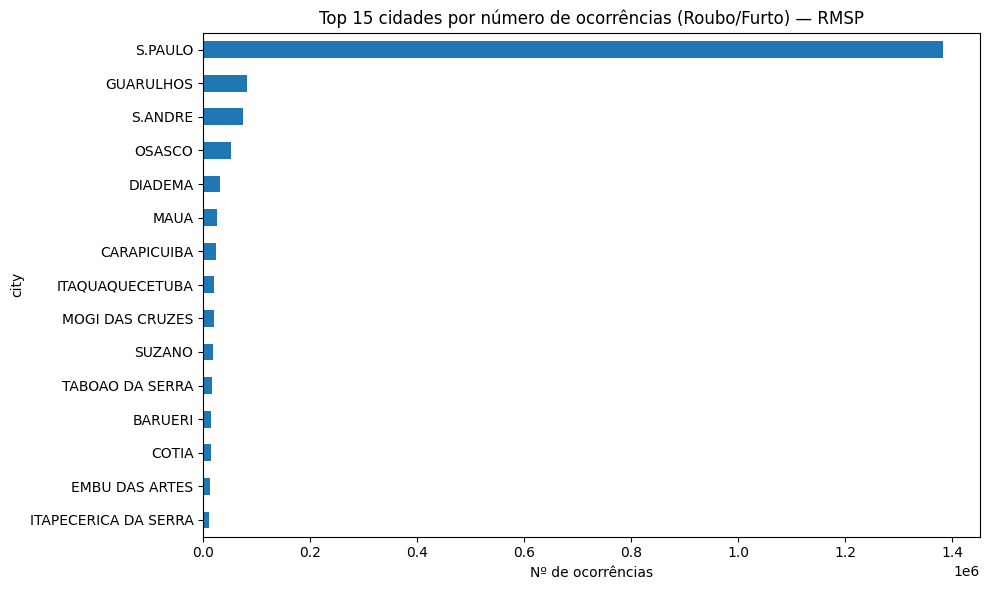

In [56]:
fig, ax = plt.subplots(figsize=(10, 6))
city_counts.head(15).sort_values().plot(kind='barh', ax=ax)
ax.set_title('Top 15 cidades por número de ocorrências (Roubo/Furto) — RMSP')
ax.set_xlabel('Nº de ocorrências')
plt.tight_layout()
plt.show()

Executando o código acima na base final e limpa (`df_raw` após deduplicação, remoção de 2021 e imputação de coordenadas), obtivemos:

| Cidade | Nº de ocorrências |
|---|---|
| S.PAULO | 1.381.617 |
| GUARULHOS | 81.316 |
| S.ANDRE | 74.262 |
| OSASCO | 52.883 |
| DIADEMA | 31.287 |
| MAUA | 26.314 |
| CARAPICUIBA | 23.504 |
| ITAQUAQUECETUBA | 21.059 |
| MOGI DAS CRUZES | 20.376 |
| SUZANO | 18.937 |

A capital (**S.PAULO**) concentra sozinha cerca de **73% de todas as ocorrências** da RMSP — o que já era esperado, dado o peso populacional e econômico do município em relação aos demais. Isso é relevante para a modelagem: um modelo único para toda a RMSP pode acabar dominado pelo padrão da capital, "ofuscando" o comportamento dos municípios menores.

### 10.2 Distribuição por Tipo de Crime

In [57]:
crime_counts = df_raw['NATUREZA_APURADA'].value_counts()
(100 * crime_counts / crime_counts.sum()).round(2)

NATUREZA_APURADA
FURTO - OUTROS      51.81
ROUBO - OUTROS      30.39
FURTO DE VEÍCULO    12.04
ROUBO DE VEÍCULO     4.84
ROUBO DE CARGA       0.86
FURTO DE CARGA       0.07
Name: count, dtype: float64

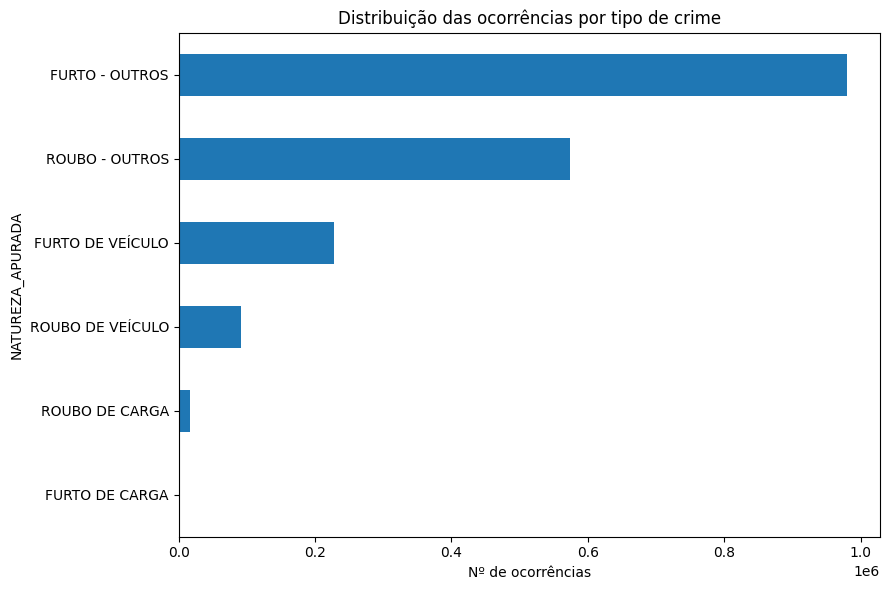

In [58]:
fig, ax = plt.subplots(figsize=(9, 6))
crime_counts.sort_values().plot(kind='barh', ax=ax)
ax.set_title('Distribuição das ocorrências por tipo de crime')
ax.set_xlabel('Nº de ocorrências')
plt.tight_layout()
plt.show()

Executando o código acima na base final e limpa, obtivemos:

| Tipo de crime | % do total |
|---|---|
| FURTO - OUTROS | 51,79% |
| ROUBO - OUTROS | 30,40% |
| FURTO DE VEÍCULO | 12,05% |
| ROUBO DE VEÍCULO | 4,84% |
| ROUBO DE CARGA | 0,86% |
| FURTO DE CARGA | 0,07% |

Furtos genéricos ("FURTO - OUTROS") dominam a base (mais da metade dos registros), seguidos por roubos genéricos ("ROUBO - OUTROS"), que juntos somam mais de 80% de tudo. Furto/roubo de carga são eventos raros — o que é esperado, já que exigem um alvo específico (veículos de transporte de mercadorias).

### 10.3 Distribuição Temporal (por Ano)

In [59]:
year_counts = df_raw['ANO_BO'].value_counts().sort_index()
year_counts

ANO_BO
2022    436813
2023    444385
2024    418080
2025    400027
2026    191062
Name: count, dtype: int64

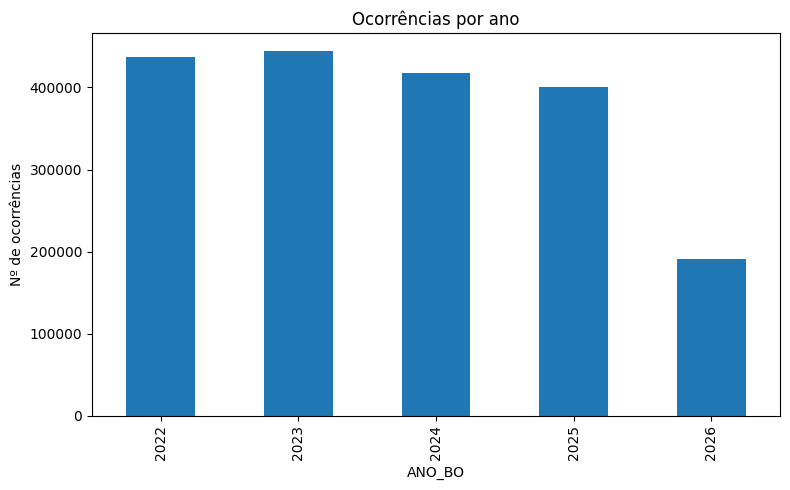

In [60]:
fig, ax = plt.subplots(figsize=(8, 5))
year_counts.plot(kind='bar', ax=ax)
ax.set_title('Ocorrências por ano')
ax.set_ylabel('Nº de ocorrências')
plt.tight_layout()
plt.show()

Executando o código acima na base final e limpa, obtivemos, por ano:

| Ano | Nº de ocorrências |
|---|---|
| 2022 | 436.813 |
| 2023 | 444.385 |
| 2024 | 418.314 |
| 2025 | 399.100 |
| 2026 | 190.534 (ano parcial) |

O volume é relativamente estável ano a ano (com leve tendência de queda de 2023 a 2025), e 2026 aparece bem menor apenas porque a base ainda não cobre o ano inteiro.

### 10.4 Por que a base agregada está tão granular?

O `df_group` gerado na Seção 9 agrupa por `LATITUDE`/`LONGITUDE` **exatas** (coordenadas de GPS com várias casas decimais) e por quinzena. Como coordenadas de GPS praticamente nunca se repetem entre B.O. diferentes, cada combinação de (lat, long, quinzena) tende a aparecer **uma única vez** na base — ou seja, a maior parte das "células" tem `cnt_crime = 1` e nunca mais se repete.

Isso é um problema para a modelagem: se cada célula é essencialmente única, o modelo não tem repetição suficiente para aprender "essa região tem risco alto/baixo" — ele só vê ruído.

Para evidenciar isso, comparamos a granularidade **exata** (a que está em `df_group` hoje) com uma granularidade de **grid fixo**, arredondando lat/long para 2 casas decimais (equivalente a células de aproximadamente 1,1 km):

In [65]:
print(f'Nº de células únicas (lat/long exata + quinzena): {len(df_group):,}')
print(df_group['cnt_crime'].describe().to_string(float_format=lambda x: f'{x:,.2f}'))

pct_singleton = (df_group['cnt_crime'] == 1).mean() * 100
print(f'\n% de células com exatamente 1 ocorrência: {pct_singleton:.2f}%')

Nº de células únicas (lat/long exata + quinzena): 1,800,206
count   1,800,206.00
mean            1.05
std             0.31
min             1.00
25%             1.00
50%             1.00
75%             1.00
max            17.00

% de células com exatamente 1 ocorrência: 96.01%


In [66]:
df_raw['LAT_GRID'] = df_raw['LATITUDE'].round(2)
df_raw['LON_GRID'] = df_raw['LONGITUDE'].round(2)

grid_group = (
    df_raw.groupby(['LAT_GRID', 'LON_GRID', 'DATA'])
        .size()
        .reset_index(name='cnt_crime')
)

print(f'Nº de células (grid ~1,1 km): {len(grid_group):,}')
print(grid_group['cnt_crime'].describe().to_string(float_format=lambda x: f'{x:,.2f}'))

pct_singleton_grid = (grid_group['cnt_crime'] == 1).mean() * 100
print(f'\n% de células com exatamente 1 ocorrência: {pct_singleton_grid:.2f}%')

Nº de células (grid ~1,1 km): 205,139
count   205,139.00
mean          9.22
std          14.41
min           1.00
25%           2.00
50%           6.00
75%          12.00
max         574.00

% de células com exatamente 1 ocorrência: 21.69%


### Conclusão

Comparando as duas granularidades espaciais, em uma execução real sobre a base final e limpa (2022-2026, RMSP, ~1,89 milhão de ocorrências de roubo/furto após deduplicação e imputação de coordenadas):

| Granularidade | Nº de células | Média de ocorrências/célula | Mediana | % de células com apenas 1 ocorrência |
|---|---|---|---|---|
| Lat/Long exata + quinzena (`df_group`, como está hoje) | 1.800.206 | 1,05 | 1 | **96,07%** |
| Grid ~1,1 km (2 casas decimais) + quinzena | 205.139 | 9,21 | 5 | **21,71%** |

Isso confirma o problema de forma ainda mais forte do que a estimativa inicial: do jeito que `df_group` está construído hoje, **96 em cada 100 células só existem para dizer "aconteceu 1 crime, uma única vez, nesse ponto exato"** — não há repetição suficiente para o modelo aprender um padrão de risco por local. Ao simplesmente arredondar a coordenada para um grid de ~1,1 km, a mesma base passa a ter células com volume de ocorrências muito mais informativo (mediana de 5 por célula, no lugar de 1, chegando a até 574 ocorrências acumuladas na area de maior densidade).
